# Spin-Chain Spectrum Notebook

This notebook follows the Mathematica reference more closely while staying in Python.

It provides one reusable class that can work in two modes:
- `basis_mode="full"` for symmetry-resolved spectral histograms
- `basis_mode="fixed"` for the fixed-$N_\uparrow$ Mathematica workflow: Hamiltonian construction, ground state, and entanglement entropy

The notebook uses NumPy/SciPy for sparse Hamiltonian construction and QuTiP for the entanglement-entropy calculation.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, product
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import svdvals
from qutip import Qobj, entropy_vn


class SpinChainSpectrum:
    """Build XXZ spin-chain Hamiltonians, diagonalize them, and plot symmetry-resolved spectra."""

    def __init__(
        self,
        L,
        Nup=None,
        basis_mode="fixed",
        periodic=True,
        J1xy=1.0,
        J1z=0.5,
        J2xy=0.0,
        J2z=0.0,
    ):
        self.L = int(L)
        self.Nup = Nup if Nup is None else int(Nup)
        self.basis_mode = basis_mode
        self.periodic = bool(periodic)
        self.J1xy = float(J1xy)
        self.J1z = float(J1z)
        self.J2xy = float(J2xy)
        self.J2z = float(J2z)

        self.basis = self._build_basis()
        self.index = {state: i for i, state in enumerate(self.basis)}
        self._P = None
        self._F = None
        self._entropy_maps = None

    def _build_basis(self):
        if self.basis_mode == "fixed":
            if self.Nup is None:
                raise ValueError("Nup must be set when basis_mode='fixed'.")
            basis = []
            for positions in combinations(range(self.L), self.Nup):
                state = [0] * self.L
                for pos in positions:
                    state[pos] = 1
                basis.append(tuple(state))
            return basis

        if self.basis_mode == "full":
            return [tuple(bits) for bits in product((0, 1), repeat=self.L)]

        raise ValueError("basis_mode must be 'fixed' or 'full'.")

    def _pairs(self, order):
        if order == 1:
            if self.periodic:
                return [(i, (i + 1) % self.L) for i in range(self.L)]
            return [(i, i + 1) for i in range(self.L - 1)]

        if order == 2:
            if self.periodic:
                return [(i, (i + 2) % self.L) for i in range(self.L)]
            return [(i, i + 2) for i in range(self.L - 2)]

        raise ValueError("order must be 1 or 2")

    def _state_int(self, state):
        value = 0
        for bit in state:
            value = (value << 1) | bit
        return value

    def _bond_diagonal(self, state, a, b, Jz):
        return (Jz / 4.0) if state[a] == state[b] else (-Jz / 4.0)

    def _bond_flip(self, state, a, b):
        flipped = list(state)
        flipped[a], flipped[b] = flipped[b], flipped[a]
        return tuple(flipped)

    def build_hamiltonian(self, kind="nn"):
        """Return the XXZ Hamiltonian as a sparse matrix."""
        if kind not in {"nn", "nnn"}:
            raise ValueError("kind must be 'nn' or 'nnn'.")

        dim = len(self.basis)
        rows, cols, vals = [], [], []
        diag = np.zeros(dim, dtype=float)

        for i, state in enumerate(self.basis):
            for a, b in self._pairs(1):
                diag[i] += self._bond_diagonal(state, a, b, self.J1z)
                if state[a] != state[b]:
                    j = self.index[self._bond_flip(state, a, b)]
                    rows.append(i)
                    cols.append(j)
                    vals.append(self.J1xy / 2.0)

            if kind == "nnn" and (self.J2xy != 0.0 or self.J2z != 0.0):
                for a, b in self._pairs(2):
                    diag[i] += self._bond_diagonal(state, a, b, self.J2z)
                    if state[a] != state[b]:
                        j = self.index[self._bond_flip(state, a, b)]
                        rows.append(i)
                        cols.append(j)
                        vals.append(self.J2xy / 2.0)

        rows.extend(range(dim))
        cols.extend(range(dim))
        vals.extend(diag.tolist())

        return coo_matrix((vals, (rows, cols)), shape=(dim, dim)).tocsr()

    def ground_state(self, kind="nnn"):
        """Return the lowest eigenvalue and eigenvector in the fixed-Nup basis."""
        if self.basis_mode != "fixed":
            raise ValueError("ground_state is intended for basis_mode='fixed'.")

        H = self.build_hamiltonian(kind=kind)
        if H.shape[0] == 1:
            return float(H[0, 0]), np.array([1.0], dtype=float)

        eigvals, eigvecs = eigsh(H, k=1, which="SA", tol=1e-12, maxiter=100000)
        return float(eigvals[0]), eigvecs[:, 0]

    def _precompute_entropy_maps(self):
        """Precompute row/column maps for all block sizes in the fixed basis."""
        if self._entropy_maps is not None:
            return self._entropy_maps

        if self.basis_mode != "fixed":
            raise ValueError("entropy maps are intended for basis_mode='fixed'.")

        maps = []
        for ell in range(self.L + 1):
            if ell == 0 or ell == self.L:
                maps.append(None)
                continue

            row_a = []
            row_b = []
            for state in self.basis:
                left = 0
                for bit in state[:ell]:
                    left = (left << 1) | bit
                right = 0
                for bit in state[ell:]:
                    right = (right << 1) | bit
                row_a.append(left)
                row_b.append(right)

            maps.append({
                "rowA": np.asarray(row_a, dtype=np.int64),
                "rowB": np.asarray(row_b, dtype=np.int64),
                "dimA": 2 ** ell,
                "dimB": 2 ** (self.L - ell),
            })

        self._entropy_maps = maps
        return maps

    def embed_state(self, sector_state):
        """Embed a fixed-basis state into the full 2^L Hilbert space."""
        if self.basis_mode != "fixed":
            raise ValueError("embed_state is intended for basis_mode='fixed'.")

        full_vec = np.zeros(2 ** self.L, dtype=complex)
        for amp, state in zip(sector_state, self.basis):
            full_vec[self._state_int(state)] = amp
        return Qobj(full_vec, dims=[[2] * self.L, [1]])

    def entropy_curve(self, kind="nnn"):
        """Compute the ground-state entanglement entropy for all block sizes."""
        ground_energy, sector_state = self.ground_state(kind=kind)
        maps = self._precompute_entropy_maps()

        block_sizes = np.arange(self.L + 1)
        entropies = np.zeros(self.L + 1, dtype=float)

        for ell in range(1, self.L):
            data = maps[ell]
            psi_matrix = coo_matrix(
                (sector_state, (data["rowA"], data["rowB"])),
                shape=(data["dimA"], data["dimB"]),
            ).toarray()
            svals = svdvals(psi_matrix)
            probs = svals**2
            probs = probs[probs > 1e-14]
            entropies[ell] = float(-np.sum(probs * np.log(probs)))

        upper_bound = np.log(2.0) * np.minimum(block_sizes, self.L - block_sizes)
        return block_sizes, entropies, upper_bound, ground_energy

    def plot_entropy(self, kind="nnn", title=None):
        """Plot entanglement entropy and the maximal-bond bound."""
        block_sizes, entropies, upper_bound, ground_energy = self.entropy_curve(kind=kind)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(block_sizes, entropies, marker="o", linewidth=2, label="Entropy")
        ax.plot(block_sizes, upper_bound, "--", linewidth=2, label="Upper Bound")
        ax.set_xlabel("Block size l")
        ax.set_ylabel("S(l)")
        ax.set_title(title or f"Entanglement Entropy (E0 = {ground_energy:.6f})")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    def parity_operator(self):
        """Reflection operator that reverses the spin chain."""
        if self.basis_mode != "full":
            raise ValueError("parity_operator is intended for basis_mode='full'.")

        if self._P is None:
            dim = len(self.basis)
            P = np.zeros((dim, dim), dtype=float)
            for i, state in enumerate(self.basis):
                P[self.index[tuple(reversed(state))], i] = 1.0
            self._P = Qobj(P)
        return self._P

    def spinflip_operator(self):
        """Global spin-flip operator (0 <-> 1 on every site)."""
        if self.basis_mode != "full":
            raise ValueError("spinflip_operator is intended for basis_mode='full'.")

        if self._F is None:
            dim = len(self.basis)
            F = np.zeros((dim, dim), dtype=float)
            for i, state in enumerate(self.basis):
                flipped = tuple(1 - x for x in state)
                F[self.index[flipped], i] = 1.0
            self._F = Qobj(F)
        return self._F

    def diagonalize(self, kind="nn"):
        """Return the full spectrum for basis_mode='full'."""
        if self.basis_mode != "full":
            raise ValueError("diagonalize is intended for basis_mode='full'.")

        H = self.build_hamiltonian(kind=kind).toarray()
        eigvals, eigvecs = np.linalg.eigh(H)
        return eigvals, eigvecs

    def symmetry_sectors(self, kind="nn"):
        """Group full-basis eigenvalues into the four (Pi, Rx) symmetry sectors."""
        eigvals, eigvecs = self.diagonalize(kind=kind)
        P = self.parity_operator()
        F = self.spinflip_operator()

        sectors = {"++": [], "+-": [], "-+": [], "--": []}
        for energy, psi in zip(eigvals, eigvecs.T):
            state = Qobj(psi)
            pi = float(np.real_if_close((state.dag() * P * state)))
            rx = float(np.real_if_close((state.dag() * F * state)))
            key = ("+" if pi >= 0 else "-") + ("+" if rx >= 0 else "-")
            sectors[key].append(float(energy))

        return eigvals, sectors

    def plot_sector_histograms(self, kind="nn", bins=24, density=True, title=None):
        """Plot the eigenvalue distribution in each symmetry sector."""
        if self.basis_mode != "full":
            raise ValueError("plot_sector_histograms is intended for basis_mode='full'.")

        eigvals, sectors = self.symmetry_sectors(kind=kind)
        all_energies = np.asarray(eigvals, dtype=float)

        if np.isscalar(bins):
            bins = np.linspace(all_energies.min(), all_energies.max(), int(bins) + 1)

        fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
        sector_order = [("++", 0, 0), ("+-", 0, 1), ("-+", 1, 0), ("--", 1, 1)]
        colors = {"++": "tab:blue", "+-": "tab:orange", "-+": "tab:green", "--": "tab:red"}
        labels = {
            "++": r"$\Pi=+, R_x^\pi=+$",
            "+-": r"$\Pi=+, R_x^\pi=-$",
            "-+": r"$\Pi=-, R_x^\pi=+$",
            "--": r"$\Pi=-, R_x^\pi=-$",
        }

        for sector, row, col in sector_order:
            ax = axes[row, col]
            values = np.array(sectors[sector], dtype=float)
            ax.hist(values, bins=bins, density=density, color=colors[sector], edgecolor="black", alpha=0.85)
            ax.set_title(f"{labels[sector]}  (N={len(values)})")
            ax.set_xlabel("Energy")
            ax.set_ylabel("Density" if density else "Count")
            ax.grid(True, alpha=0.2)

        fig.suptitle(title or f"Symmetry-resolved spectrum ({kind.upper()})", y=1.02)
        plt.show()


Full basis dimension = 1024


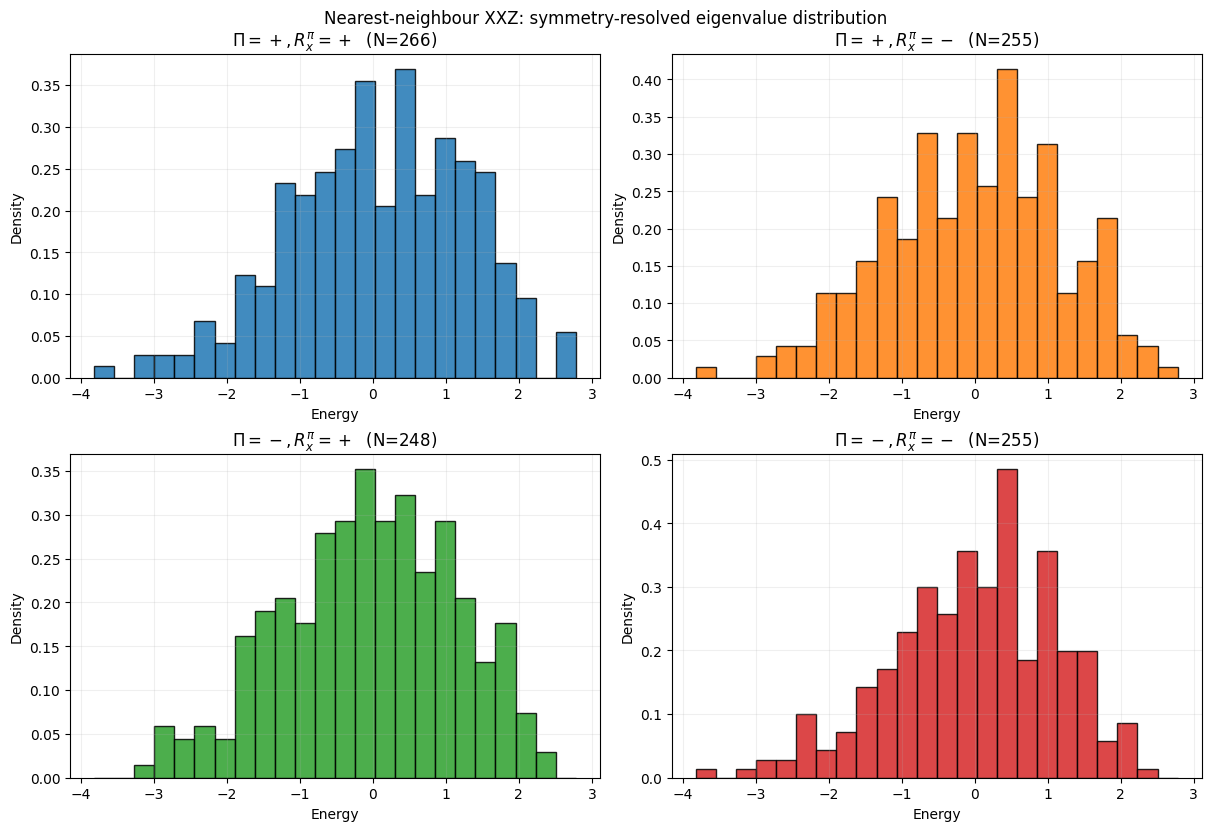

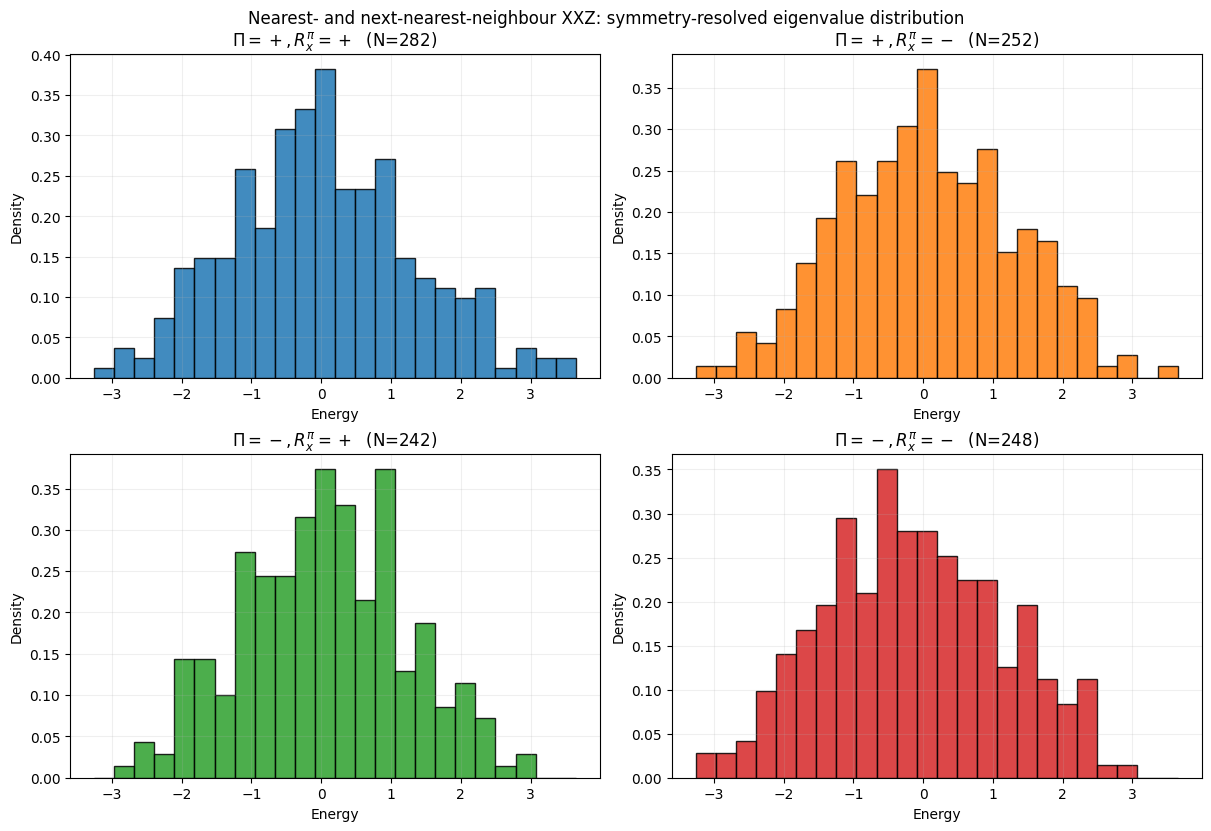

Fixed-Nup basis dimension = 2002
Ground state energy = -4.3611222954915050


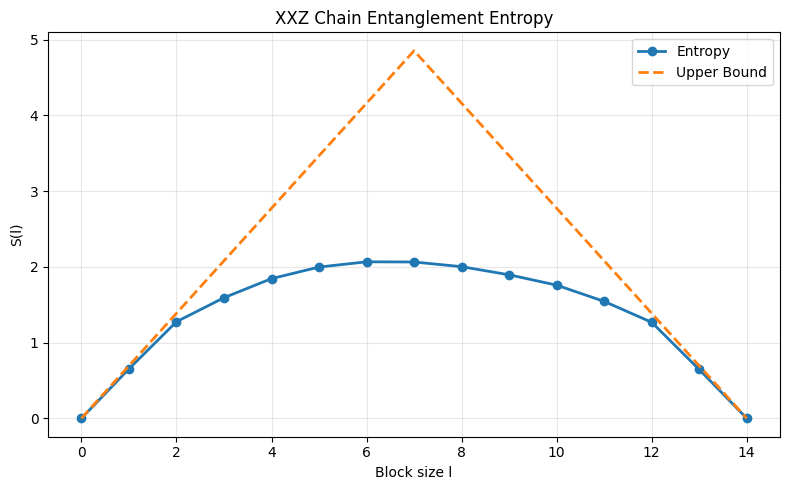

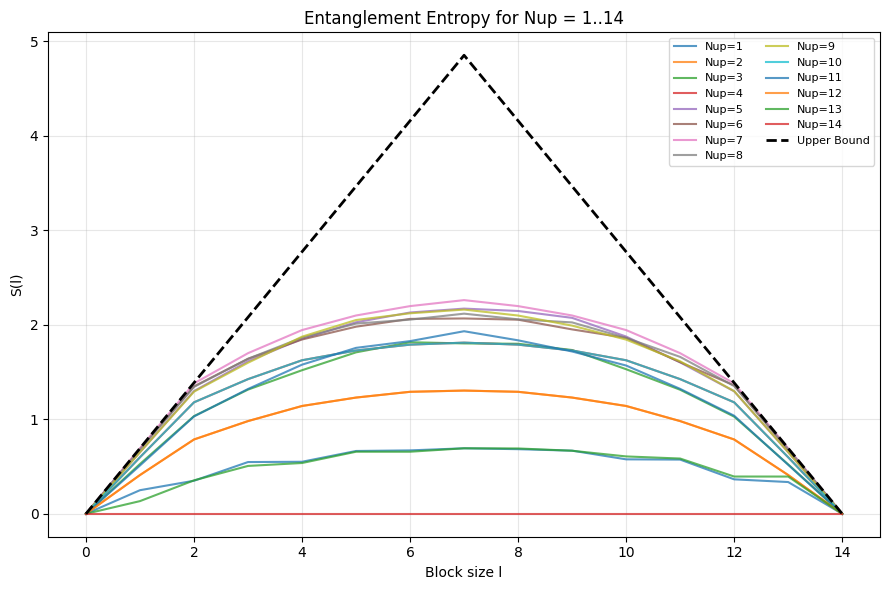

In [7]:
# Demo 1: symmetry-resolved spectra for a modest full-basis chain.
# Full-basis diagonalization scales as 2^L, so keep this demo small.
full_chain = SpinChainSpectrum(
    L=10,
    basis_mode="full",
    periodic=True,
    J1xy=1.0,
    J1z=0.5,
    J2xy=0.35,
    J2z=0.20,
)

print(f"Full basis dimension = {len(full_chain.basis)}")
full_chain.plot_sector_histograms(
    kind="nn",
    bins=24,
    density=True,
    title="Nearest-neighbour XXZ: symmetry-resolved eigenvalue distribution",
)
full_chain.plot_sector_histograms(
    kind="nnn",
    bins=24,
    density=True,
    title="Nearest- and next-nearest-neighbour XXZ: symmetry-resolved eigenvalue distribution",
)

# Demo 2: Mathematica-style fixed-Nup chain for the entropy calculation.
fixed_chain = SpinChainSpectrum(
    L=14,
    Nup=5,
    basis_mode="fixed",
    periodic=True,
    J1xy=1.0,
    J1z=0.5,
    J2xy=1.0,
    J2z=0.0,
)

print(f"Fixed-Nup basis dimension = {len(fixed_chain.basis)}")
energy, _ = fixed_chain.ground_state(kind="nnn")
print(f"Ground state energy = {energy:.16f}")
fixed_chain.plot_entropy(
    kind="nnn",
    title="XXZ Chain Entanglement Entropy",
)

# Demo 3: sweep Nup from 1 to L and overlay all entropy curves on one final graph.
# This matches the request to graph each instance separately, but keeps the output compact.
L_sweep = 14
nup_values = range(1, L_sweep + 1)

fig, ax = plt.subplots(figsize=(9, 6))
for nup in nup_values:
    sweep_chain = SpinChainSpectrum(
        L=L_sweep,
        Nup=nup,
        basis_mode="fixed",
        periodic=True,
        J1xy=1.0,
        J1z=-1.0,
        J2xy=1.0,
        J2z=1.0,
    )
    block_sizes, entropies, upper_bound, ground_energy = sweep_chain.entropy_curve(kind="nnn")
    ax.plot(block_sizes, entropies, linewidth=1.5, alpha=0.75, label=f"Nup={nup}")

ax.plot(block_sizes, upper_bound, "k--", linewidth=2, label="Upper Bound")
ax.set_xlabel("Block size l")
ax.set_ylabel("S(l)")
ax.set_title(f"Entanglement Entropy for Nup = 1..{L_sweep}")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


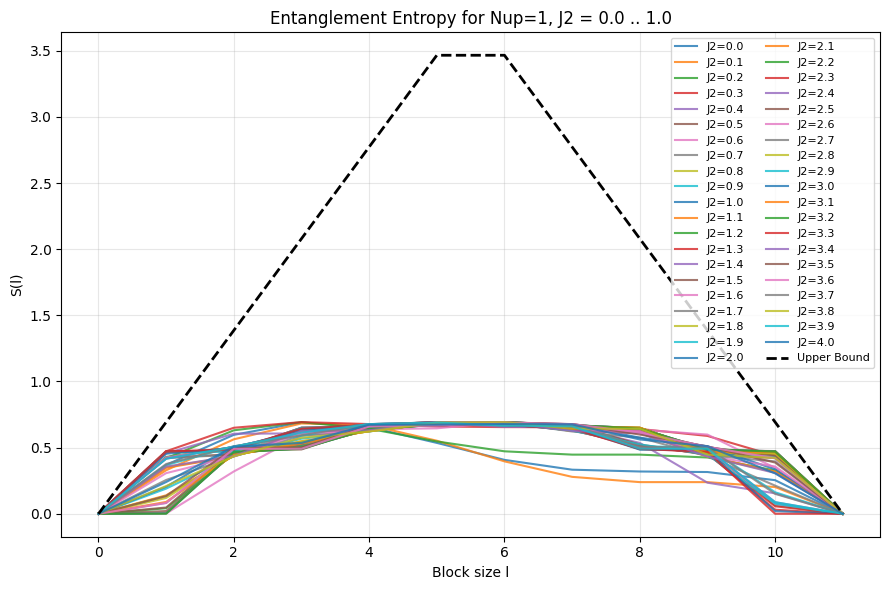

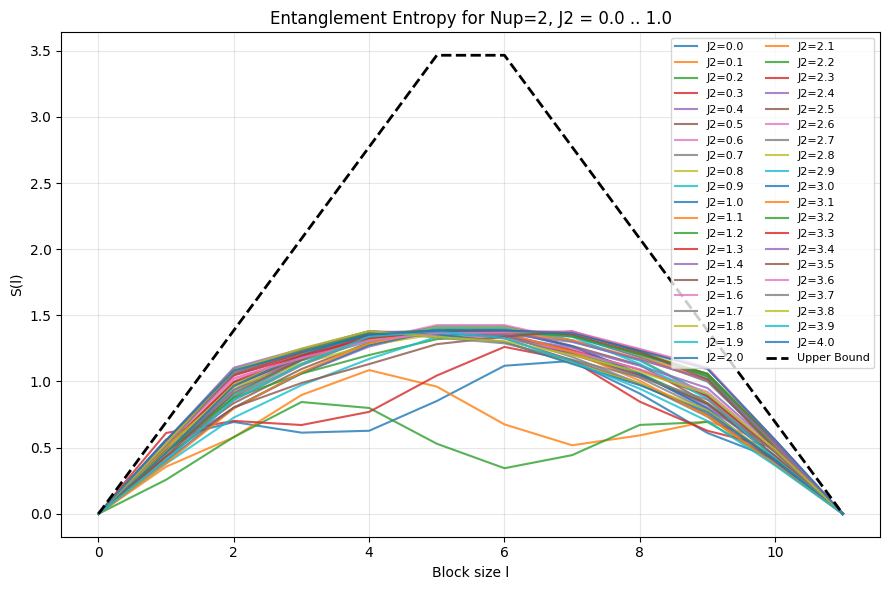

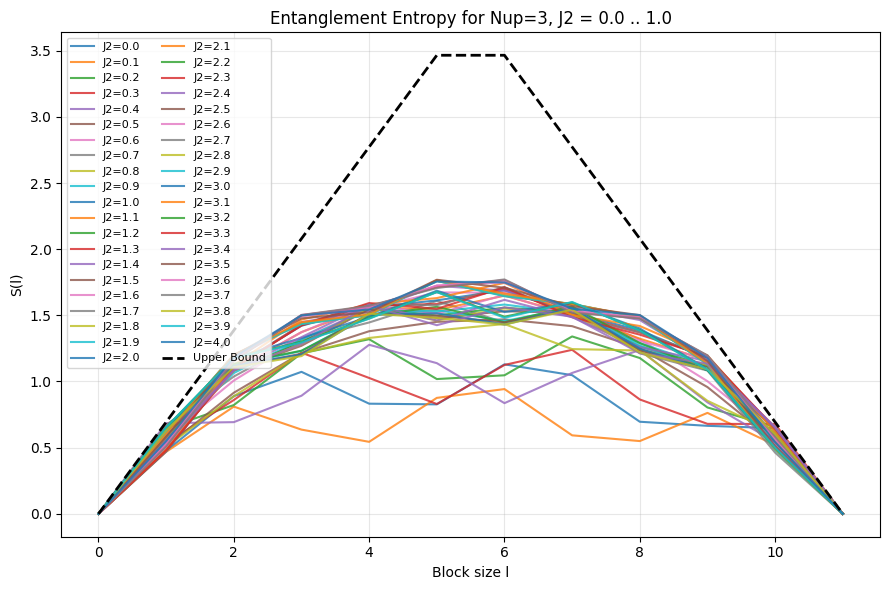

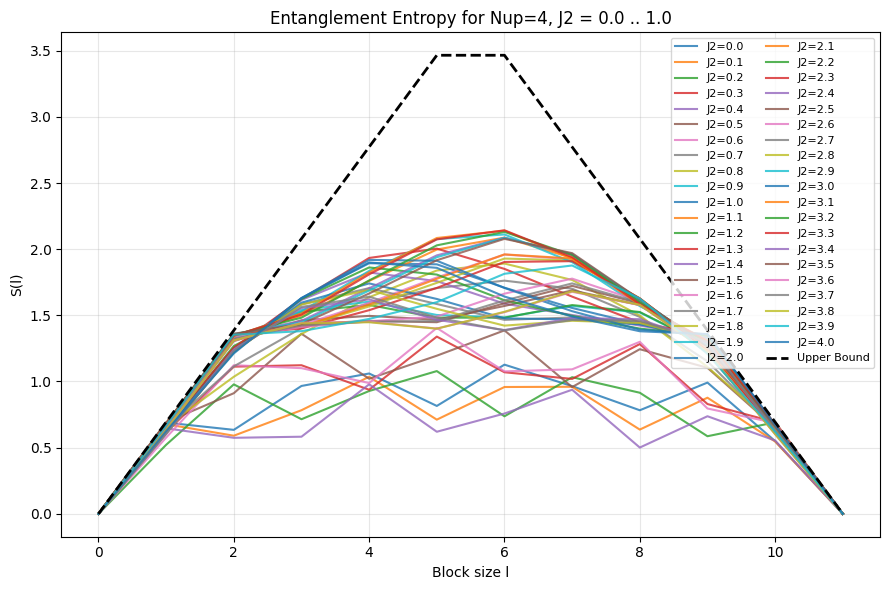

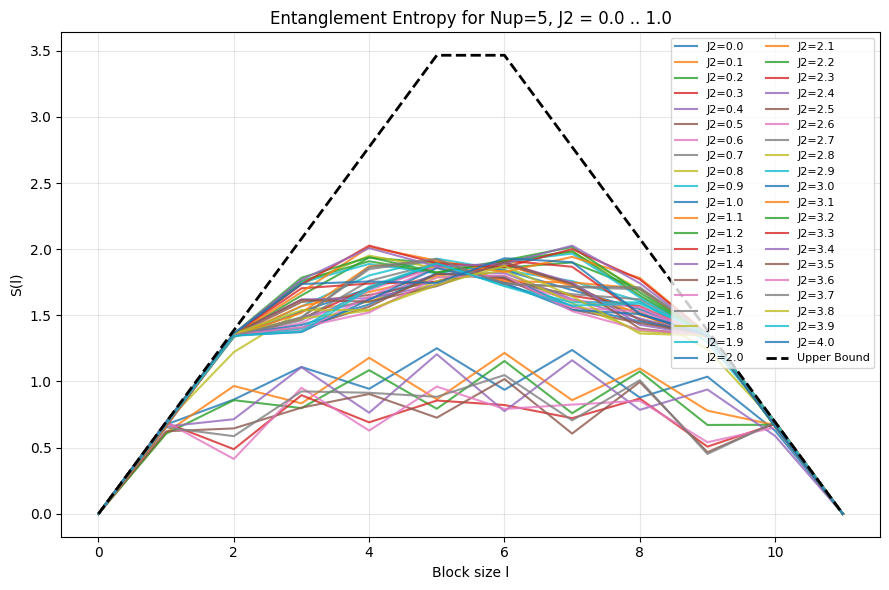

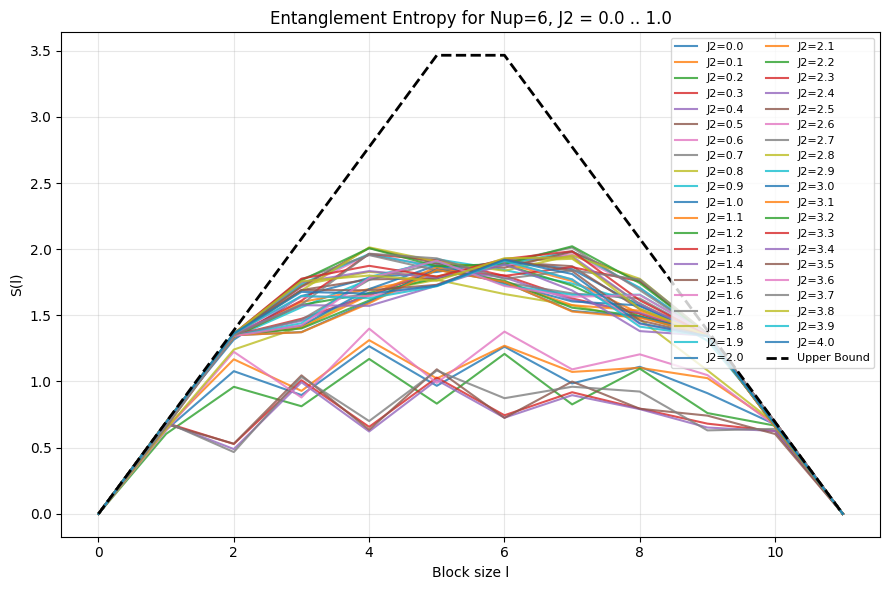

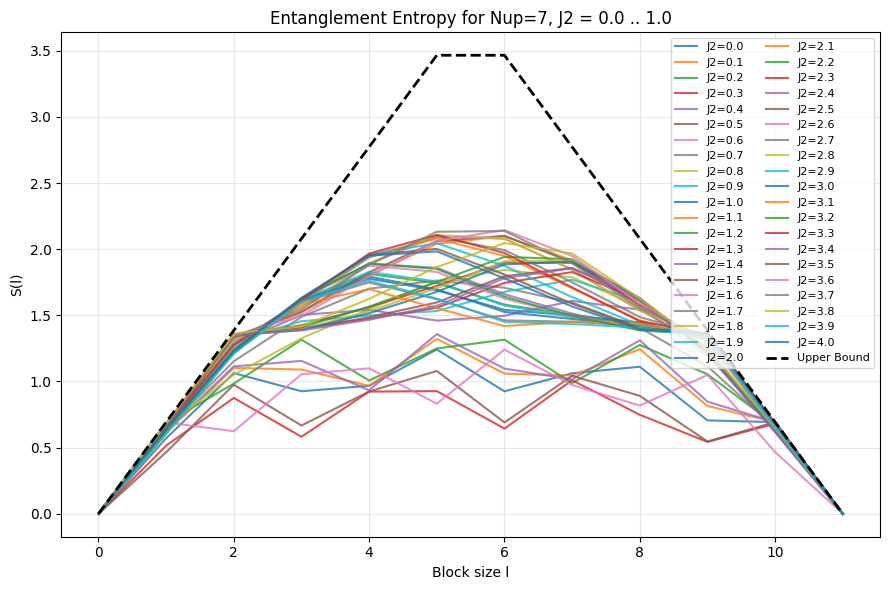

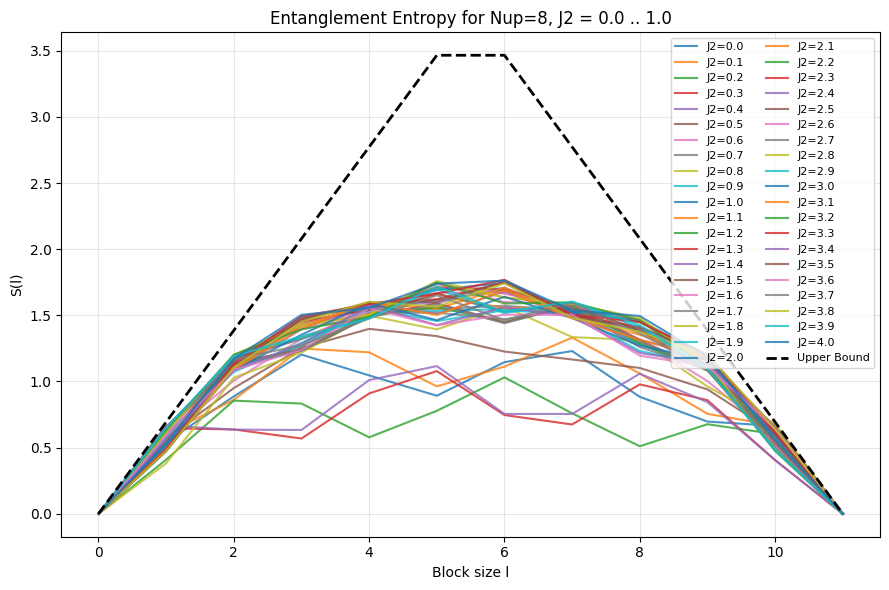

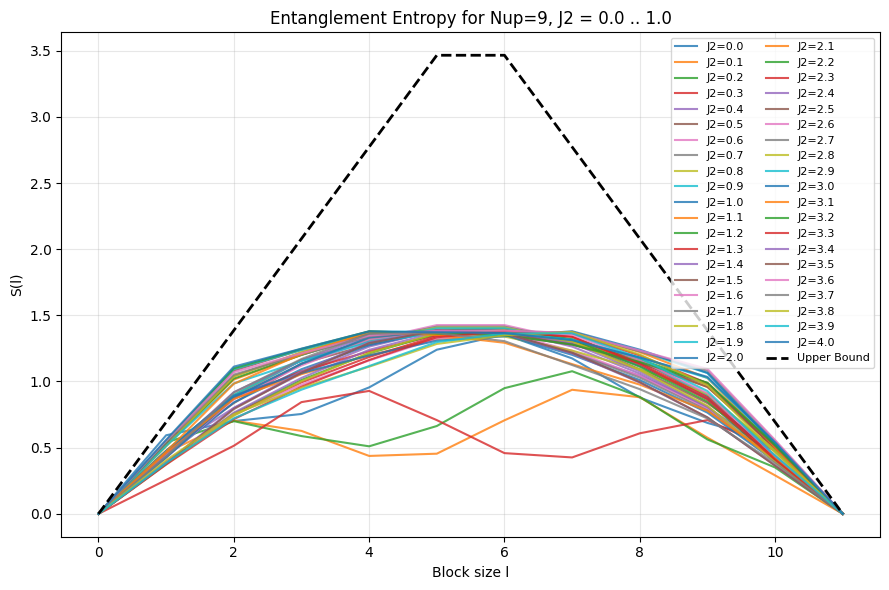

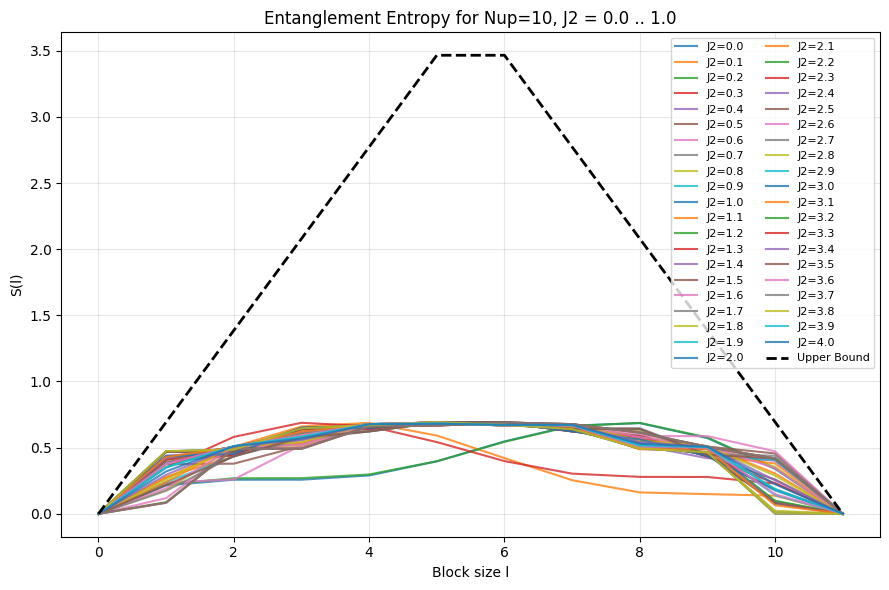

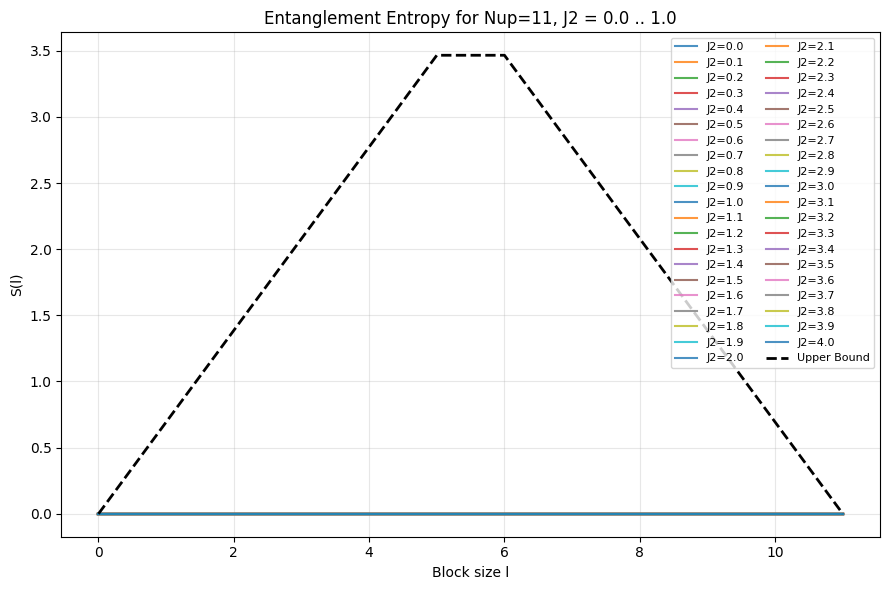

In [21]:
# Demo 4: sweep J2 from 0 to 1 in steps of 0.1 and make one graph per Nup value.
# Here J2 is used as the NNN XY coupling, with the NNN ZZ term kept at zero.
L_j2 = 11
Nup_j2_values = range(1, L_j2 + 1)
J2_values = np.round(np.arange(0.0, 4.0 + 1e-9, 0.1), 1)

for Nup_j2 in Nup_j2_values:
    fig, ax = plt.subplots(figsize=(9, 6))
    for J2_val in J2_values:
        j2_chain = SpinChainSpectrum(
            L=L_j2,
            Nup=Nup_j2,
            basis_mode="fixed",
            periodic=True,
            J1xy=1.0,
            J1z=0.5,
            J2xy=float(J2_val),
            J2z=0.0,
        )
        block_sizes, entropies, upper_bound, ground_energy = j2_chain.entropy_curve(kind="nnn")
        ax.plot(block_sizes, entropies, linewidth=1.5, alpha=0.8, label=f"J2={J2_val:.1f}")

    ax.plot(block_sizes, upper_bound, "k--", linewidth=2, label="Upper Bound")
    ax.set_xlabel("Block size l")
    ax.set_ylabel("S(l)")
    ax.set_title(f"Entanglement Entropy for Nup={Nup_j2}, J2 = 0.0 .. 1.0")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


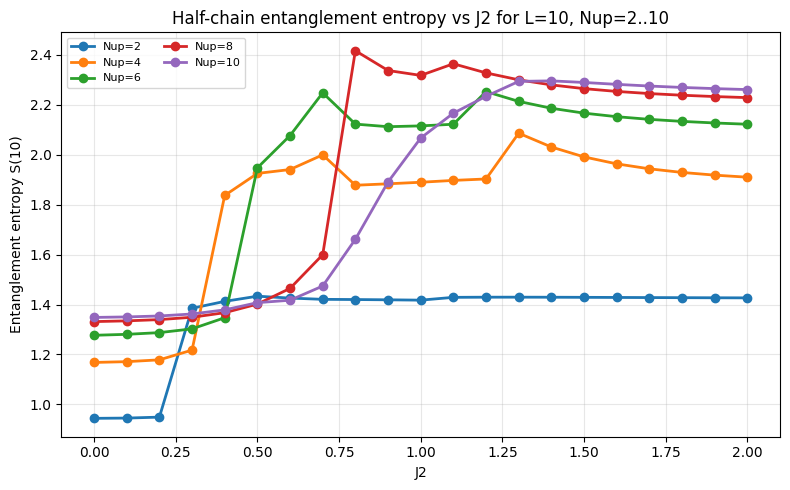

In [20]:
# Demo 5: entanglement entropy vs J2 for L = 10 and Nup = 2..10.
# Each Nup gets its own curve on the same axes.
L_entropy = 20
Nup_entropy_values = range(2, (L_entropy//2 )+1, 2)
J2_scan = np.round(np.arange(0.0, 2.0 + 1e-9, 0.1), 1)
mid_block = L_entropy // 2

fig, ax = plt.subplots(figsize=(8, 5))
for Nup_entropy in Nup_entropy_values:
    entropy_vs_J2 = []
    for J2_val in J2_scan:
        entropy_chain = SpinChainSpectrum(
            L=L_entropy,
            Nup=Nup_entropy,
            basis_mode="fixed",
            periodic=True,
            J1xy=1.0,
            J1z=0.5,
            J2xy=float(J2_val),
            J2z=0.0,
        )
        block_sizes, entropies, upper_bound, ground_energy = entropy_chain.entropy_curve(kind="nnn")
        entropy_vs_J2.append(entropies[mid_block])

    ax.plot(J2_scan, entropy_vs_J2, marker="o", linewidth=2, label=f"Nup={Nup_entropy}")

ax.set_xlabel("J2")
ax.set_ylabel(f"Entanglement entropy S({mid_block})")
ax.set_title("Half-chain entanglement entropy vs J2 for L=10, Nup=2..10")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()
